The 8 images that are in the WebDataset but not in the yfcc_index table are shown below. 

These images are either truncated or can't be identified as an image file.

https://storage.cmusatyalab.org/yfcc100m/yfcc100m. base: https://storage.cmusatyalab.org/yfcc100m name: yfcc100m nfiles: 403 nbytes: 1264357191680 samples: 10016544 cache: /tmp/_wids_cache
/home/ubuntu/yfcc-scope/.venv/lib/python3.10/site-packages/wids/wids.py:316: UserWarning: String specifications for transformations are deprecated. Use functions instead.
  warnings.warn("String specifications for transformations are deprecated. Use functions instead.")


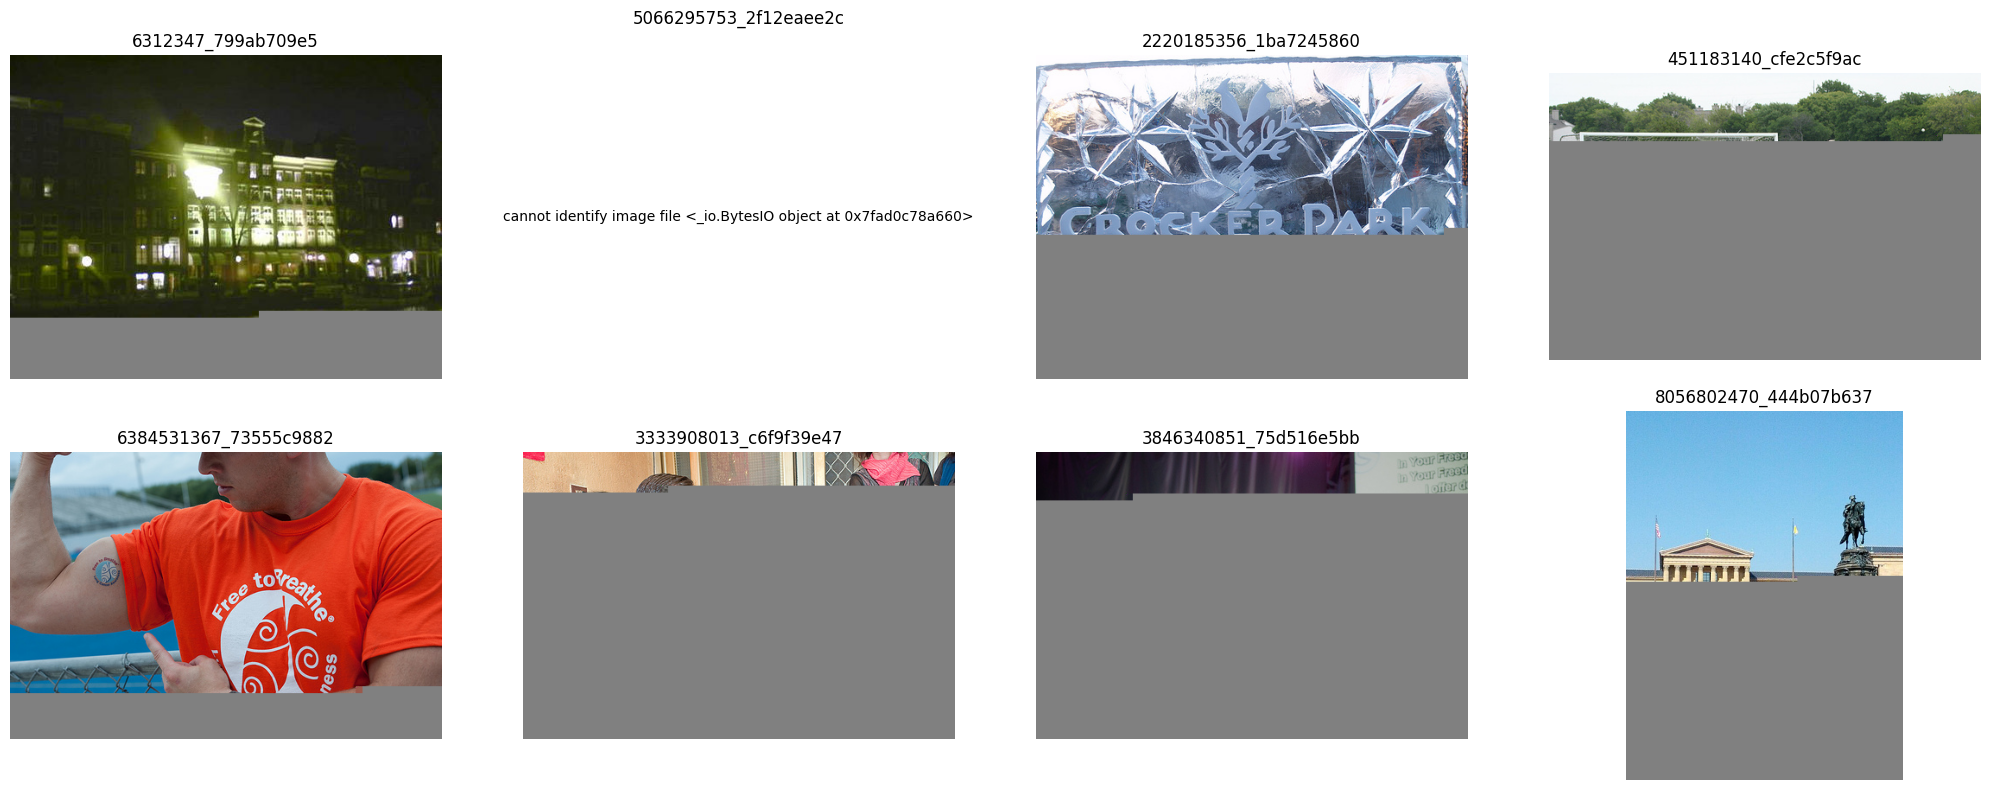

In [1]:
import math
import matplotlib.pyplot as plt
from PIL import Image
from PIL import ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

import wids

YFCC_URL = "https://storage.cmusatyalab.org/yfcc100m/yfcc100m.json"
ds = wids.ShardListDataset(YFCC_URL)

# (index, file_id, crc) for the missing images in the yfcc_index table
info = [
    (65654, '6312347', '799ab709e5'),
    (4181860, '5066295753', '2f12eaee2c'),
    (5187739, '2220185356', '1ba7245860'),
    (5187741, '451183140', 'cfe2c5f9ac'),
    (5220037, '6384531367', '73555c9882'),
    (5220038, '3333908013', 'c6f9f39e47'),
    (5249999, '3846340851', '75d516e5bb'),
    (5303954, '8056802470', '444b07b637'),
]

import math
import matplotlib.pyplot as plt

num = len(info)
cols = 4
rows = math.ceil(num / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for i, (idx, file_id, crc) in enumerate(info):
    try:
        axes[i].imshow(ds[idx][".jpg"])
        axes[i].set_title(f"{file_id}_{crc}")
        axes[i].axis("off")

    except Exception as e:
        axes[i].set_title(f"{file_id}_{crc}")
        axes[i].text(0.5, 0.5, str(e), ha="center", va="center", wrap=True)
        axes[i].axis("off")

for j in range(num, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()